In [1]:
## Standard libraries
import os
import json
import math
import numpy as np
from typing import Any, Sequence
import pickle
from copy import deepcopy

## Imports for plotting
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
sns.set()

## Progress bar
from tqdm.auto import tqdm

## JAX
import jax
import jax.numpy as jnp
from jax import random
import flax
from flax import linen as nn
from flax.training import train_state
import optax

In [2]:
import orbax.checkpoint as ocp
from pathlib import Path
import os

DATASET_PATH = f"{os.environ['PWD']}/data"
OUTPUT = Path(f"{os.environ['PWD']}/checkpoints_2")
OUTPUT.mkdir(exist_ok=True)

ckpt_dir = ocp.test_utils.erase_and_create_empty(OUTPUT)
checkpointer = ocp.StandardCheckpointer()

In [3]:
class Sigmoid(nn.Module):
    def __call__(self, x):
        return 1/(1+jnp.exp(-x))

class Tanh(nn.Module):
    def __call__(self, x):
        return (jnp.exp(2*x)-1)/(jnp.exp(2*x)+1)

class ReLU(nn.Module):
    def __call__(self, x):
        return jnp.maximum(x, 0)

class LeakyReLU(nn.Module):
    alpha: float = 0.1
    
    def __call__(self, x):
        return jnp.where(x>0, x, x*self.alpha)

class ELU(nn.Module):
    alpha: float = 1.0
    
    def __call__(self, x):
        return jnp.where(x>0, x, (jnp.exp(x)-1)*self.alpha)

class SiLU(nn.Module):
    alpha: float = 1.0
    
    def __call__(self, x):
        return x * nn.sigmoid(x)

class GELU(nn.Module):
    def __call__(self, x):
        return x * jax.scipy.stats.norm.cdf(x)

In [4]:
act_fn_by_name = {
    "sigmoid": Sigmoid,
    "tanh": Tanh,
    "relu": ReLU,
    "leakyrelu": LeakyReLU,
    "elu": ELU,
    "swish": SiLU,
    "gelu": GELU
}

In [5]:
def get_grads(act_fn, x):
    return jax.vmap(jax.grad(act_fn))(x)

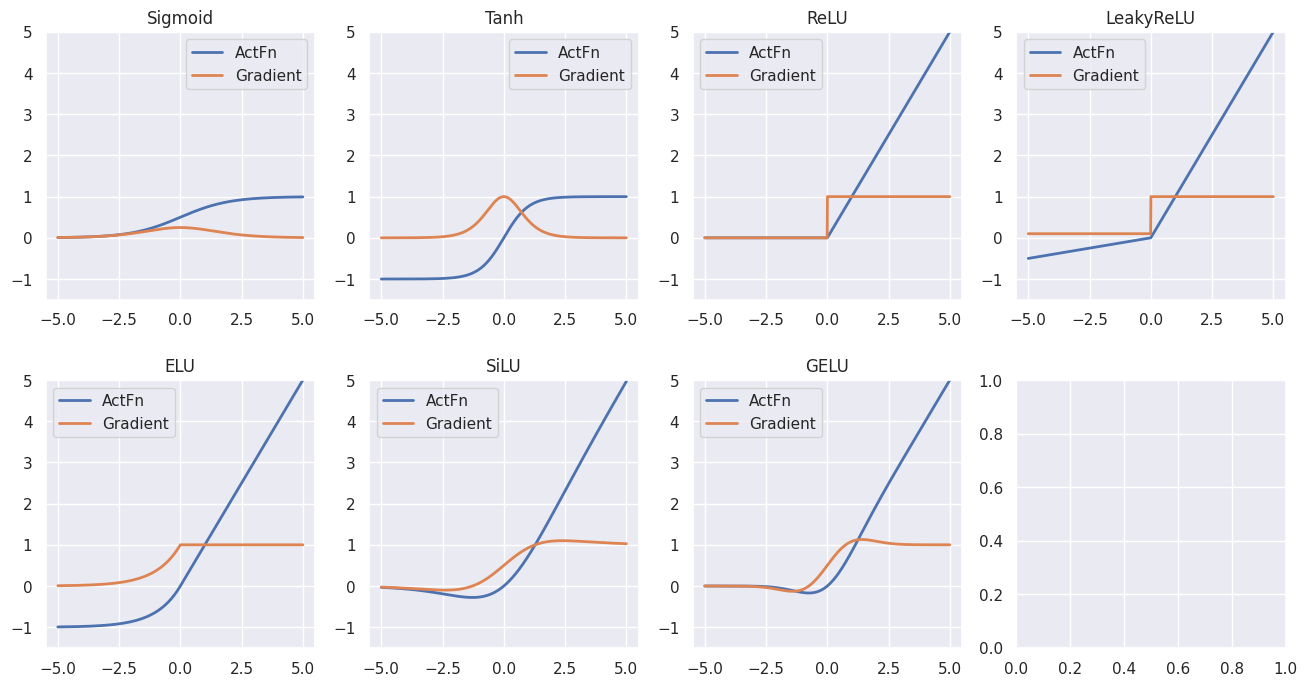

In [10]:
def vis_act_fn(act_fn, ax, x):
    # Run activation function
    y = act_fn(x)
    y_grads = get_grads(act_fn, x)
    # Push x, y and gradients back to cpu for plotting
    # x, y, y_grads = x.cpu().numpy(), y.cpu().numpy(), y_grads.cpu().numpy()
    ## Plotting
    ax.plot(x, y, linewidth=2, label="ActFn")
    ax.plot(x, y_grads, linewidth=2, label="Gradient")
    ax.set_title(act_fn.__class__.__name__)
    ax.legend()
    ax.set_ylim(-1.5, x.max())

# Add activation functions if wanted
act_fns = [act_fn() for act_fn in act_fn_by_name.values()]
x = np.linspace(-5, 5, 1000) # Range on which we want to visualize the activation functions
## Plotting
cols = math.ceil(len(act_fns)/2.0)
fig, ax = plt.subplots(2, cols, figsize=(cols*4, 8))
for i, act_fn in enumerate(act_fns):
    vis_act_fn(act_fn, ax[divmod(i,cols)], x)
fig.subplots_adjust(hspace=0.3)
plt.show()